**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of multiple fluorophores](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [PFA data](#toc1_1_1_)    
      - [2 fluorophores](#toc1_1_1_1_)    
      - [3 Fluorophores](#toc1_1_1_2_)    
      - [4 fluorophores](#toc1_1_1_3_)    
  - [Figure](#toc1_2_)    
    - [Preparation](#toc1_2_1_)    
    - [Figure](#toc1_2_2_)    
    - [Figure with locs](#toc1_2_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of multiple fluorophores](#toc0_)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.figure as fi
import fluopy.fitting as fitting
import fluopy.miscellaneous as mi
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

reading_from_1 = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_4_multi_f_PFA"
)
reading_from_2 = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling"

## <a id='toc1_1_'></a>[Reading data](#toc0_)

### <a id='toc1_1_1_'></a>[PFA data](#toc0_)

#### <a id='toc1_1_1_1_'></a>[2 fluorophores](#toc0_)

In [2]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_2f_all = []
parameters_2f_all = []
locs_2f_all = []
for i, id in enumerate(identifiers):
    fingerprints_2f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    locs_2f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    for file in Path(reading_from_1 + "/2F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_2f_all[i] += pd.read_parquet(file).sum(axis=1)
            locs_2f_all[i] += (pd.read_parquet(file) > 0).sum(axis=1)
    fingerprint = fingerprints_2f_all[i].cumsum() / fingerprints_2f_all[i].sum()
    fingerprints_2f_all[i] = fingerprint
    locs_2f = locs_2f_all[i].cumsum() / locs_2f_all[i].sum()
    locs_2f_all[i] = locs_2f
    parameter_file = reading_from_2 + f"/2F/{id}/parameters_2F_{id}.npy"
    parameter_dict = fitting.load_from_array(parameter_file)
    parameters_2f_all.append(parameter_dict)

#### <a id='toc1_1_1_2_'></a>[3 Fluorophores](#toc0_)

In [3]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_3f_all = []
parameters_3f_all = []
locs_3f_all = []
for i, id in enumerate(identifiers):
    fingerprints_3f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    locs_3f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    for file in Path(reading_from_1 + "/3F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_3f_all[i] += pd.read_parquet(file).sum(axis=1)
            locs_3f_all[i] += (pd.read_parquet(file) > 0).sum(axis=1)
    fingerprint = fingerprints_3f_all[i].cumsum() / fingerprints_3f_all[i].sum()
    fingerprints_3f_all[i] = fingerprint
    locs_3f = locs_3f_all[i].cumsum() / locs_3f_all[i].sum()
    locs_3f_all[i] = locs_3f
    parameter_file = reading_from_2 + f"/3F/{id}/parameters_3F_{id}.npy"
    parameter_dict = fitting.load_from_array(parameter_file)
    parameters_3f_all.append(parameter_dict)

#### <a id='toc1_1_1_3_'></a>[4 fluorophores](#toc0_)

In [4]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_4f_all = []
fingerprints_4f_all_truncated = []
OFF_periods_4f_all = []
ON_periods_4f_all = []
number_ON_periods_4f_all = []
intensities_4f_all = []
parameters_4f_all = []
locs_4f_all = []
locs_4f_all_truncated = []
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_4f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    locs_4f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_4f_all.append([])
    ON_periods_4f_all.append([])
    intensities_4f_all.append([])
    number_ON_periods_4f_all.append([])
    for file in Path(reading_from_1 + "/4F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            data = pd.read_parquet(file)
            non_zero = data[data > 0].values.flatten()
            non_zero = non_zero[~np.isnan(non_zero)]
            fingerprints_4f_all[i] += data.sum(axis=1)
            locs_4f_all[i] += (data > 0).sum(axis=1)
            intensities_4f_all[i] += non_zero.tolist()
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                OFF_periods_4f_all[i] += blinks.off_periods.tolist()
                ON_periods_4f_all[i] += blinks.on_periods.tolist()
                number_ON_periods_4f_all[i].append(blinks.on_periods.size)
    fingerprint = fingerprints_4f_all[i].cumsum() / fingerprints_4f_all[i].sum()
    fingerprints_4f_all[i] = fingerprint
    loc_fingerprint = locs_4f_all[i].cumsum() / locs_4f_all[i].sum()
    locs_4f_all[i] = loc_fingerprint
    fingerprint_truncated = rt.truncate_fingerprints(
        fingerprint,
        low=3000,
    )
    fingerprints_4f_all_truncated.append(fingerprint_truncated)
    locs_4f_truncated = rt.truncate_fingerprints(
        loc_fingerprint,
        low=3000,
    )
    locs_4f_all_truncated.append(locs_4f_truncated)
    parameter_file = reading_from_2 + f"/4F/{id}/parameters_4F_{id}.npy"
    parameter_dict = fitting.load_from_array(parameter_file)
    parameters_4f_all.append(parameter_dict)

## <a id='toc1_2_'></a>[Figure](#toc0_)

### <a id='toc1_2_1_'></a>[Preparation](#toc0_)

In [5]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins


OFF_periods_4f_all = [
    np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_4f_all
]
log_bins_OFF_4f = get_log_bins(OFF_periods_4f_all)
weights_OFF_4f = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_4f_all
]
ON_periods_4f_all = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_4f_all]
log_bins_ON_4f = get_log_bins(ON_periods_4f_all)
weights_ON_4f = [
    np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_4f_all
]
intensities_4f_all = [np.array(intensities) for intensities in intensities_4f_all]
weights_intensities_4f = [
    np.ones_like(intensities) / len(intensities) for intensities in intensities_4f_all
]

number_ON_periods_4f_all = [
    np.array(number_ON_periods) for number_ON_periods in number_ON_periods_4f_all
]
weights_number_ON_periods = [
    np.ones_like(number_ON_periods) / number_ON_periods.size
    for number_ON_periods in number_ON_periods_4f_all
]

In [11]:
print("OFF periods (s)")
for i, off_periods in enumerate(OFF_periods_4f_all):
    print(f"{identifiers[i]}: {np.mean(off_periods)}")
print()
print("ON periods (s)")
for i, on_periods in enumerate(ON_periods_4f_all):
    print(f"{identifiers[i]}: {np.mean(on_periods)}")
print()
print("Intensities (photons / ms)")
for i, intensities in enumerate(intensities_4f_all):
    print(f"{identifiers[i]}: {np.mean(intensities)}")

OFF periods (s)
3nm: 9.784615200836196
6nm: 4.982268143459915
9nm: 3.3729587788733046
18nm: 3.2431136222360357

ON periods (s)
3nm: 0.2128842499280161
6nm: 0.09130172443584339
9nm: 0.037381955885044844
18nm: 0.03194641837586192

Intensities (photons / ms)
3nm: 459.5662034590273
6nm: 374.64058388967106
9nm: 173.12213369470678
18nm: 145.26969618445173


### <a id='toc1_2_2_'></a>[Figure](#toc0_)

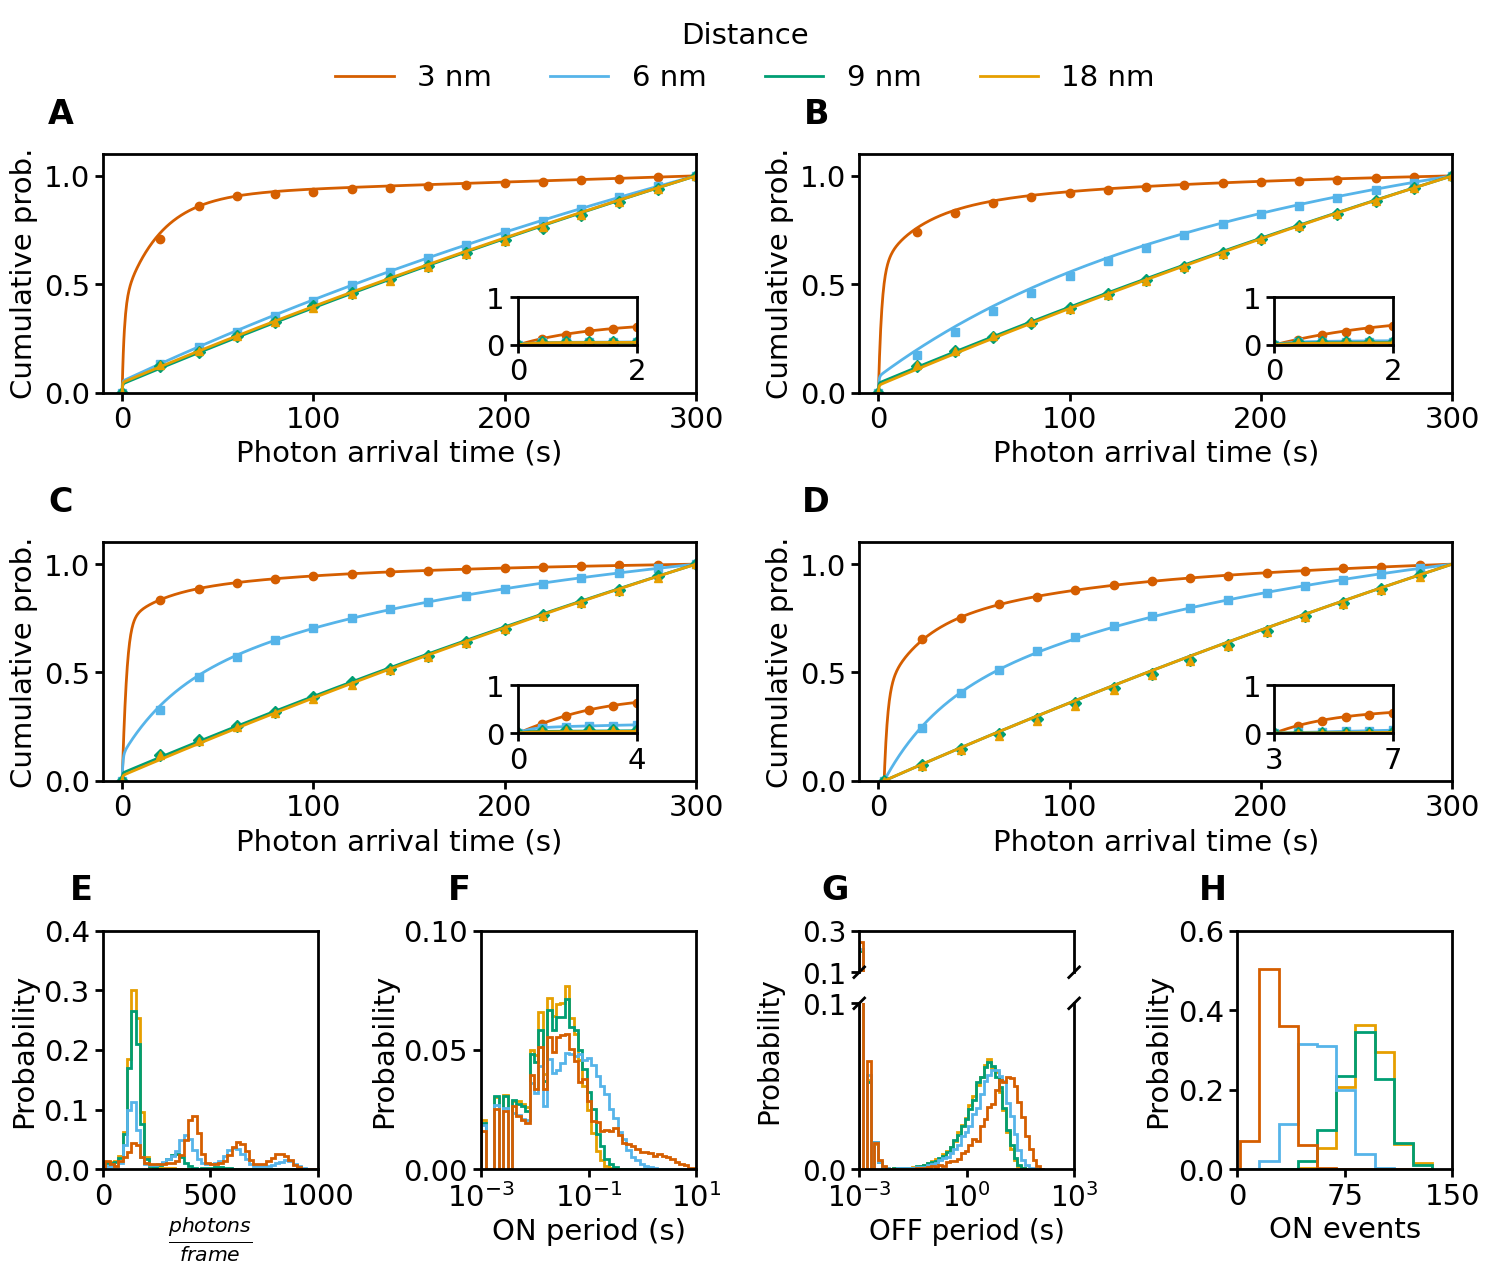

In [7]:
from matplotlib.lines import Line2D

red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax,
    labels,
    data,
    fit,
    xlim2,
    ylim2,
    spacing2,
    inset_x_ticks,
    colors=colors,
    truncated=None,
):
    if truncated is not None:
        domain = truncated
    else:
        domain = (0, 300)
    markers = ["o", "s", "D", "^"]
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            marker=marker,
            linestyle="",
            axes=ax,
        )
        fi.universal_figure(
            data=[
                x,
                dist.Photoswitching_fingerprint_model(
                    params=parameters, domain=domain
                ).cdf(x),
            ],
            lw=2,
            color=color,
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        **description,
    )

    inset = ax.inset_axes([0.7, 0.2, 0.2, 0.2], xlim=xlim2, ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            marker=marker,
            linestyle="",
        )
        fi.universal_figure(
            data=[
                x,
                dist.Photoswitching_fingerprint_model(
                    params=parameters, domain=domain
                ).cdf(x),
            ],
            lw=2,
            color=color,
            axes=inset,
        )
    inset.set_ylabel("")
    inset.set_xlabel("")
    inset.set_xticks(inset_x_ticks)


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(15, 12))


labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
legendtitle1 = "Distance"
ax1 = fig.add_subplot(gs[0, 0:2])
plot_figure3(
    ax1,
    labels1,
    fingerprints_2f_all,
    parameters_2f_all,
    (0, 2),
    1,
    400,
    [0, 2],
)

ax2 = fig.add_subplot(gs[0, 2:])
plot_figure3(
    ax2,
    labels1,
    fingerprints_3f_all,
    parameters_3f_all,
    (0, 2),
    1,
    400,
    [0, 2],
)

ax3 = fig.add_subplot(gs[1, 0:2])
plot_figure3(
    ax3,
    labels1,
    fingerprints_4f_all,
    parameters_4f_all,
    (0, 4),
    1,
    800,
    [0, 4],
)

ax4 = fig.add_subplot(gs[1, 2:])
plot_figure3(
    ax4,
    labels1,
    fingerprints_4f_all_truncated,
    parameters_4f_all,
    (3, 7),
    1,
    800,
    [3, 7],
    truncated=(3, 300),
)

ax5 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    type_="hist",
    data=intensities_4f_all,
    axes=ax5,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    bins=50,
    weights=weights_intensities_4f,
    ylabel="Probability",
    xlabel=r"$\frac{photons}{frame}$",
    ylim=[0, 0.4],
    xlim=[0, 1000],
)
ax6 = fig.add_subplot(gs[2, 1])
fi.universal_figure(
    type_="hist",
    data=ON_periods_4f_all,
    axes=ax6,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    bins=log_bins_ON_4f,
    weights=weights_ON_4f,
    xscale="log",
    ylabel="Probability",
    xlabel="ON period (s)",
    ylim=[0, 0.1],
    yticks=[0, 0.05, 0.1],
    xlim=[1e-3, 1e1],
)

bax7 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[2, 2],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax7.hist(
    OFF_periods_4f_all,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    color=colors,
    alpha=1,
    bins=log_bins_OFF_4f,
    weights=weights_OFF_4f,
)
bax7.set_xscale("log")
bax7.set_ylabel("Probability", fontsize=20, labelpad=55)
bax7.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax7.tick_params(labelsize=20, width=2, length=6)
bax7.set_xlim([1e-3, 1e3])
bax7.set_xticks([1e-3, 1e0, 1e3])
bax7.axs[0].set_yticks([0.1, 0.3])
bax7.axs[1].set_yticks([0, 0.1])

ax8 = fig.add_subplot(gs[2, 3])
fi.universal_figure(
    type_="hist",
    data=number_ON_periods_4f_all,
    axes=ax8,
    density=False,
    histtype="step",
    lw=2,
    label=labels1,
    alpha=1,
    color=colors,
    ylabel="Probability",
    xlabel="ON events",
    xlim=[0, 150],
    ylim=[0, 0.6],
    xticks=[0, 75, 150],
    weights=weights_number_ON_periods,
)

letters = ["A", "B", "C", "D", "E", "F", "G", "H"]
axes = fig.get_axes()
j = 0
for i, axis in enumerate(axes):
    if i in [6, 7]:
        continue
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1

custom_handles = [
    Line2D([0], [0], color=red, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=orange, lw=2),
]

fig.legend(
    custom_handles,
    labels1,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.07),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)
fig.tight_layout()
for handle in bax7.diag_handles:
    handle.remove()
bax7.draw_diags()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)

fig.savefig(
    reading_from_1 + r"\multi_f_PFA.png",
    bbox_inches=bbox,
    dpi=300,
)

### <a id='toc1_2_3_'></a>[Figure with locs](#toc0_)

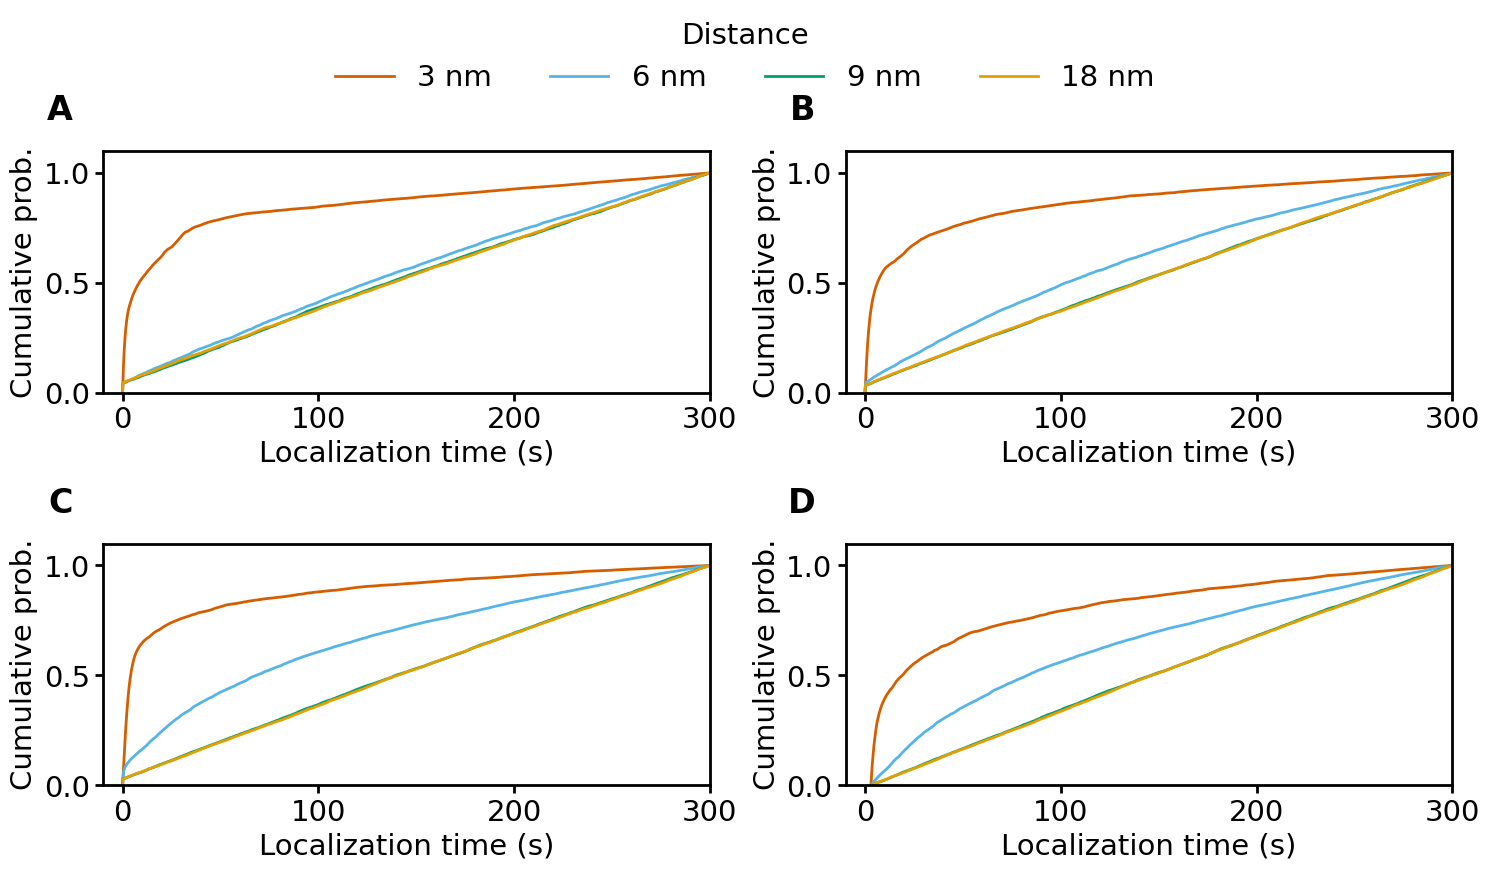

: 

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

custom_handles = [
    Line2D([0], [0], color=red, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=orange, lw=2),
]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(2, 4)
fig = plt.figure(figsize=(15, 8))


ax1 = fig.add_subplot(gs[0, 0:2])
for fingerprint, label, color in zip(locs_2f_all, labels1, colors):
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        label=label,
        color=color,
        marker=None,
        linestyle="-",
        lw=2,
        ylabel="Cumulative prob.",
        xlabel="Localization time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
        axes=ax1,
    )

ax2 = fig.add_subplot(gs[0, 2:])
for fingerprint, label, color in zip(locs_3f_all, labels1, colors):
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        label=label,
        color=color,
        marker=None,
        linestyle="-",
        lw=2,
        ylabel="Cumulative prob.",
        xlabel="Localization time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
        axes=ax2,
    )

ax3 = fig.add_subplot(gs[1, 0:2])
for fingerprint, label, color in zip(locs_4f_all, labels1, colors):
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        label=label,
        color=color,
        marker=None,
        linestyle="-",
        lw=2,
        ylabel="Cumulative prob.",
        xlabel="Localization time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
        axes=ax3,
    )

ax4 = fig.add_subplot(gs[1, 2:])
for fingerprint, label, color in zip(locs_4f_all_truncated, labels1, colors):
    fi.universal_figure(
        data=[fingerprint.index, fingerprint],
        label=label,
        color=color,
        marker=None,
        linestyle="-",
        lw=2,
        ylabel="Cumulative prob.",
        xlabel="Localization time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
        axes=ax4,
    )


letters = ["A", "B", "C", "D"]
axes = fig.get_axes()
j = 0
for axis in axes:
    axis.text(
        -0.05,
        1.1,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1

fig.legend(
    custom_handles,
    labels1,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.1),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)
fig.tight_layout()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)

fig.savefig(reading_from_1 + r"\multi_f_PFA_as_locs.png", dpi=300, bbox_inches=bbox)